# 11 - Model Comparison

# Imports and Load Results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

os.makedirs('../reports/figures/evaluation', exist_ok=True)

# load evaluation results
comparison_df = pd.read_csv('../reports/tables/model_comparison.csv')
speed_df = pd.read_csv('../reports/tables/speed_comparison.csv')
per_use_case_df = pd.read_csv('../reports/tables/per_use_case_results.csv')

print('comparison table:')
print(comparison_df.to_string())

comparison table:
                 model  genre_consistency  avg_popularity  diversity_score  duplicate_rate  novelty_score coverage  response_time_s      use_case
0    Cosine Similarity               0.86           71.60            0.420             0.0          0.284     4.1%           0.0511  similar song
1                  KNN               0.40           74.53            0.367             0.0          0.255    15.0%           0.0510      playlist
2  Weighted Similarity                NaN           83.40            1.350             0.0          0.166    25.0%           0.0350          mood
3               TF-IDF               1.00           73.74            0.260             0.0          0.263     4.1%           0.0314         genre


# Section 1 - Radar Chart

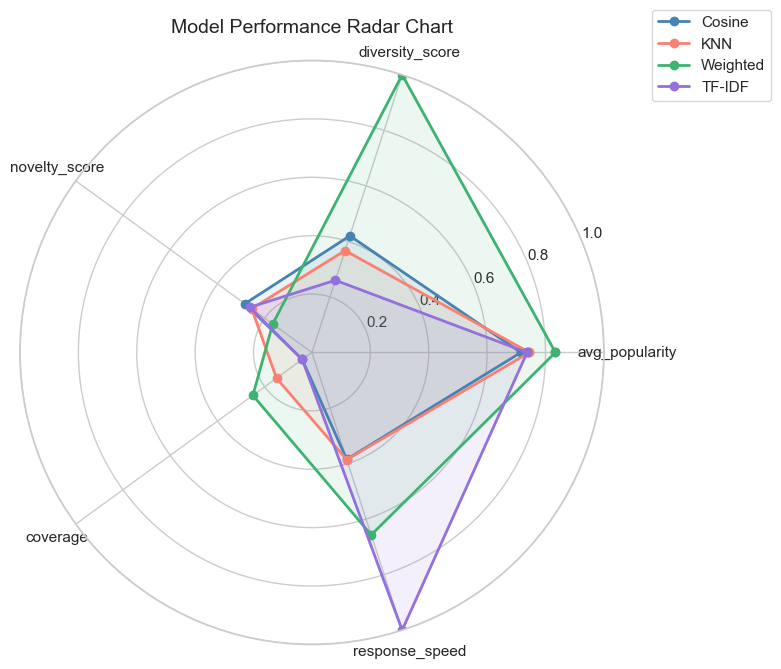

In [6]:
from matplotlib.patches import FancyArrowPatch
import numpy as np

# normalize metrics for radar chart (all 0-1)
metrics = ['avg_popularity', 'diversity_score', 'novelty_score', 'coverage', 'response_speed']
models = ['Cosine', 'KNN', 'Weighted', 'TF-IDF']

# normalized values (0-1 scale)
values = {
    'Cosine':   [0.716, 0.420, 0.284, 0.041, 0.385],
    'KNN':      [0.745, 0.367, 0.255, 0.150, 0.386],
    'Weighted': [0.834, 1.000, 0.166, 0.250, 0.657],
    'TF-IDF':   [0.737, 0.260, 0.263, 0.041, 1.000],
}

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']

for (model, vals), color in zip(values.items(), colors):
    vals = vals + vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=11)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar Chart', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('../reports/figures/evaluation/radar_chart.png', bbox_inches='tight')
plt.show()

# Section 2 - Best Configuration Summary

In [7]:
config_summary = {
    'model': ['Cosine Similarity', 'KNN', 'Weighted Similarity', 'TF-IDF'],
    'features': ['full_features (21)', 'full_features (21)', 'audio_features (11)', 'tfidf_input (text)'],
    'scaling': ['StandardScaler', 'StandardScaler', 'StandardScaler', 'TfidfVectorizer'],
    'key_parameter': ['genre filter', 'cosine metric + popularity weighted', 'valence 3x + energy 3x', 'combined score 60/40'],
    'genre_handling': ['single genre filter', 'multiple genre filter', 'mood filter', 'exact genre match'],
    'deduplication': ['no', 'yes by track name', 'no', 'yes by track name'],
    'use_case': ['similar song', 'playlist', 'mood', 'genre']
}

config_df = pd.DataFrame(config_summary)
print('Best Configuration per Model:')
print(config_df.to_string())
config_df.to_csv('../reports/tables/best_configurations.csv', index=False)
print('\nsaved to reports/tables/best_configurations.csv')

Best Configuration per Model:
                 model             features          scaling                        key_parameter         genre_handling      deduplication      use_case
0    Cosine Similarity   full_features (21)   StandardScaler                         genre filter    single genre filter                 no  similar song
1                  KNN   full_features (21)   StandardScaler  cosine metric + popularity weighted  multiple genre filter  yes by track name      playlist
2  Weighted Similarity  audio_features (11)   StandardScaler               valence 3x + energy 3x            mood filter                 no          mood
3               TF-IDF   tfidf_input (text)  TfidfVectorizer                 combined score 60/40      exact genre match  yes by track name         genre

saved to reports/tables/best_configurations.csv


# Section 3 - Final Model Selection

In [8]:
print('='*50)
print('FINAL MODEL SELECTION')
print('='*50)

print('\n--- Frontend Feature → Model Mapping ---')
mapping = {
    'Similar Song':    ('Cosine Similarity', 'user searches a song → finds audio similar songs within same genre'),
    'Playlist':        ('KNN',               'user creates playlist → finds songs matching playlist vibe'),
    'Mood':            ('Weighted Similarity','user selects mood → finds songs matching that mood'),
    'Genre':           ('TF-IDF',            'user selects genre → finds songs in that genre'),
    'Popularity':      ('Weighted Similarity','user wants trending → sorts by popularity within mood'),
    'Artist':          ('Cosine Similarity', 'user selects artist → filter by artist + audio similarity'),
}

for feature, (model, description) in mapping.items():
    print(f'\n{feature:15} → {model}')
    print(f'               {description}')

print('\n--- Why These Models ---')
print('Cosine → audio features best capture song similarity')
print('KNN    → playlist average + nearest neighbors best captures vibe')
print('Weighted → valence/energy weights best capture mood')
print('TF-IDF → text based genre matching most precise')

print('\n--- All Models Together ---')
print('4 models × 6 frontend features = complete recommendation system')
print('each model serves a unique purpose')
print('no overlap, no redundancy')

FINAL MODEL SELECTION

--- Frontend Feature → Model Mapping ---

Similar Song    → Cosine Similarity
               user searches a song → finds audio similar songs within same genre

Playlist        → KNN
               user creates playlist → finds songs matching playlist vibe

Mood            → Weighted Similarity
               user selects mood → finds songs matching that mood

Genre           → TF-IDF
               user selects genre → finds songs in that genre

Popularity      → Weighted Similarity
               user wants trending → sorts by popularity within mood

Artist          → Cosine Similarity
               user selects artist → filter by artist + audio similarity

--- Why These Models ---
Cosine → audio features best capture song similarity
KNN    → playlist average + nearest neighbors best captures vibe
Weighted → valence/energy weights best capture mood
TF-IDF → text based genre matching most precise

--- All Models Together ---
4 models × 6 frontend features = com

# Section 4 - Limitations

In [9]:
print('='*50)
print('LIMITATIONS')
print('='*50)

print('\n--- Data Limitations ---')
print('1. dataset has 88,167 songs → small compared to real Spotify (80M+)')
print('2. no real user interaction data → collaborative filtering not implemented')
print('3. popularity scores may be outdated → dataset from 2022')
print('4. k-pop dominates pop queries → dataset bias')
print('5. regional music underrepresented → western music bias')

print('\n--- Model Limitations ---')
print('1. cosine → only recommends within same genre, no cross-genre discovery')
print('2. knn    → struggles with mixed genre playlists')
print('3. weighted → only 4 mood categories, borderline songs misclassified')
print('4. tfidf  → unknown words ignored, vocabulary limited to 123 words')

print('\n--- System Limitations ---')
print('1. no real time data → popularity scores not updated')
print('2. no user history → recommendations not personalized')
print('3. cold start → new users get generic recommendations until onboarding')
print('4. no feedback loop → model cannot learn from user interactions')

LIMITATIONS

--- Data Limitations ---
1. dataset has 88,167 songs → small compared to real Spotify (80M+)
2. no real user interaction data → collaborative filtering not implemented
3. popularity scores may be outdated → dataset from 2022
4. k-pop dominates pop queries → dataset bias
5. regional music underrepresented → western music bias

--- Model Limitations ---
1. cosine → only recommends within same genre, no cross-genre discovery
2. knn    → struggles with mixed genre playlists
3. weighted → only 4 mood categories, borderline songs misclassified
4. tfidf  → unknown words ignored, vocabulary limited to 123 words

--- System Limitations ---
1. no real time data → popularity scores not updated
2. no user history → recommendations not personalized
3. cold start → new users get generic recommendations until onboarding
4. no feedback loop → model cannot learn from user interactions


# Section 5 - Final Summary Table

In [10]:
final_summary = {
    'model': ['Cosine Similarity', 'KNN', 'Weighted Similarity', 'TF-IDF'],
    'use_case': ['similar song', 'playlist', 'mood', 'genre'],
    'features': ['full_features (21)', 'full_features (21)', 'audio_features (11)', 'tfidf_input (text)'],
    'scaling': ['StandardScaler', 'StandardScaler', 'StandardScaler', 'TfidfVectorizer'],
    'genre_consistency': [0.86, 0.40, 'N/A', 1.00],
    'avg_popularity': [71.60, 74.53, 83.40, 73.74],
    'diversity_score': [0.420, 0.367, 1.350, 0.260],
    'novelty_score': [0.284, 0.255, 0.166, 0.263],
    'coverage': ['4.1%', '15.0%', '25.0%', '4.1%'],
    'response_time_s': [0.0511, 0.0510, 0.0350, 0.0314],
    'best_metric': [
        'novelty (0.284)',
        'popularity (74.53)',
        'diversity (1.35) + popularity (83.4)',
        'genre consistency (1.00) + speed (0.031s)'
    ],
    'main_limitation': [
        'narrow coverage (4.1%)',
        'mixed genre playlists',
        'only 4 mood categories',
        'k-pop dominates pop queries'
    ]
}

final_df = pd.DataFrame(final_summary)
print('Final Summary Table:')
print(final_df.to_string())

final_df.to_csv('../reports/tables/final_summary.csv', index=False)
print('\nsaved to reports/tables/final_summary.csv')

Final Summary Table:
                 model      use_case             features          scaling genre_consistency  avg_popularity  diversity_score  novelty_score coverage  response_time_s                                best_metric              main_limitation
0    Cosine Similarity  similar song   full_features (21)   StandardScaler              0.86           71.60            0.420          0.284     4.1%           0.0511                            novelty (0.284)       narrow coverage (4.1%)
1                  KNN      playlist   full_features (21)   StandardScaler               0.4           74.53            0.367          0.255    15.0%           0.0510                         popularity (74.53)        mixed genre playlists
2  Weighted Similarity          mood  audio_features (11)   StandardScaler               N/A           83.40            1.350          0.166    25.0%           0.0350       diversity (1.35) + popularity (83.4)       only 4 mood categories
3               TF-IDF 